# Optimize Diffrax Solver Settings for the FAS ODE System

This notebook benchmarks multiple Diffrax solver methods and controller settings on the same reaction network used in `run_model.ipynb`.

Optimization target:
- Minimize wall-clock solve time
- Minimize number of solver steps
- Keep only successful solves

The notebook reports:
- Fastest successful configuration
- Fewest-step successful configuration
- A balanced winner using rank(time) + rank(steps)
- Pareto-optimal configurations

In [8]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../')

from pathlib import Path
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import diffrax as dfrx

from Utilities.reaction_model_builder import (
    build_ode_system_from_reactions,
    load_elementary_reactions,
    make_namespace,
    set_scaling_group_values,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Load the same reaction system as run_model.ipynb
REACTIONS_PATH = Path('../Reactions/EC_FAS_ME1')
network, species, params, param_values, scaling_groups = build_ode_system_from_reactions(REACTIONS_PATH)
rxns = load_elementary_reactions(REACTIONS_PATH)
sp = make_namespace(species)

theta_base = jnp.array([param_values[p] for p in params], dtype=jnp.float64)

# Initial concentrations (uM)
y0 = np.zeros(len(species), dtype=np.float64)
y0[sp.C2_AcCoA] = 500.0
y0[sp.C3_MalCoA] = 500.0
y0[sp.ACP] = 10.0
y0[sp.NADPH] = 1000.0
y0[sp.NADH] = 1000.0

enzyme_concs = {
    sp.FabD: 1, sp.FabH: 1, sp.FabG: 1, sp.FabZ: 1,
    sp.FabI: 1, sp.TesA: 10, sp.FabF: 1, sp.FabA: 1, sp.FabB: 1,
}
for idx, conc in enzyme_concs.items():
    y0[idx] = float(conc)

SCALING_GROUPS = {
    'a1': 1, 'a2': 1, 'a3': 1,
    'b1': 1, 'b2': 1, 'b3': 1,
    'c1': 1, 'c2': 1, 'c3': 1, 'c4': 1,
    'd1': 0, 'd2': 0, 'e': 1, 'f': 1,
    'x1': 1, 'x2': 1, 'x3': 1, 'x4': 1,
}
theta = set_scaling_group_values(theta_base, params, SCALING_GROUPS)

time_range = (0.0, 720.0)
print(f'Loaded {len(species)} species, {len(params)} params, {len(rxns)} reactions.')

Loaded 320 species, 222 params, 334 reactions.


## Benchmark Helpers

- The solver catalog is built dynamically from Diffrax names so missing classes are skipped automatically.
- The search cell uses staged presets: solver first, then tolerances, then dt0/PID, then adjoints.
- The `full_grid` stage exhaustively tests the configured grid and is the only staged option that guarantees the best result inside that finite grid.
- Each configuration runs optional warm-up solves to reduce one-time compilation bias.
- Any failed solve is retained in the table for diagnosis and excluded from optimality selection.

In [10]:
def available_solver_factories():
    candidate_names = [
        'Kvaerno3', 'Kvaerno4', 'Kvaerno5',
        'KenCarp3', 'KenCarp4', 'KenCarp5',
        'ImplicitEuler',
        'Tsit5', 'Dopri5',
    ]
    factories = {}
    for name in candidate_names:
        cls = getattr(dfrx, name, None)
        if cls is not None:
            factories[name] = cls
    return factories

def available_adjoint_factories():
    candidate_names = [
        'RecursiveCheckpointAdjoint',
        'DirectAdjoint',
        'BacksolveAdjoint',
        'ImplicitAdjoint',
    ]
    factories = {}
    for name in candidate_names:
        cls = getattr(dfrx, name, None)
        if cls is not None:
            factories[name] = cls
    return factories

def run_once(*, solver_obj, adjoint_obj, rtol, atol, pcoeff, icoeff, dcoeff, dt0, max_steps):
    t0, t1 = time_range
    tic = time.perf_counter()
    sol = dfrx.diffeqsolve(
        dfrx.ODETerm(network),
        solver_obj,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=jnp.asarray(y0, dtype=jnp.float64),
        args=theta,
        saveat=dfrx.SaveAt(steps=True),
        stepsize_controller=dfrx.PIDController(
            rtol=rtol, atol=atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff
        ),
        adjoint=adjoint_obj,
        max_steps=max_steps,
        throw=True,
    )
    _ = jax.block_until_ready(sol.ys)
    elapsed = time.perf_counter() - tic

    success = bool(dfrx.is_successful(sol.result))
    stats = dict(sol.stats)
    num_steps = int(np.asarray(stats.get('num_steps', np.nan)))
    num_accepted = int(np.asarray(stats.get('num_accepted_steps', np.nan)))
    t_final = float(np.asarray(sol.ts[num_accepted - 1])) if num_accepted > 0 else np.nan

    return {
        'success': success,
        'elapsed_s': elapsed,
        'num_steps': num_steps,
        'num_accepted_steps': num_accepted,
        't_final': t_final,
    }

def benchmark_config(cfg, repeats=2, warmup=True):
    solver_cls = cfg['solver_cls']
    solver_name = cfg['solver_name']
    adjoint_cls = cfg['adjoint_cls']
    adjoint_name = cfg['adjoint_name']

    def make_solver():
        return solver_cls()

    def make_adjoint():
        return adjoint_cls()

    if warmup:
        try:
            _ = run_once(
                solver_obj=make_solver(),
                adjoint_obj=make_adjoint(),
                rtol=cfg['rtol'],
                atol=cfg['atol'],
                pcoeff=cfg['pcoeff'],
                icoeff=cfg['icoeff'],
                dcoeff=cfg['dcoeff'],
                dt0=cfg['dt0'],
                max_steps=cfg['max_steps'],
            )
        except Exception:
            pass

    trials = []
    errors = []
    for _ in range(repeats):
        try:
            out = run_once(
                solver_obj=make_solver(),
                adjoint_obj=make_adjoint(),
                rtol=cfg['rtol'],
                atol=cfg['atol'],
                pcoeff=cfg['pcoeff'],
                icoeff=cfg['icoeff'],
                dcoeff=cfg['dcoeff'],
                dt0=cfg['dt0'],
                max_steps=cfg['max_steps'],
            )
            trials.append(out)
        except Exception as exc:
            errors.append(str(exc))

    row = {
        'stage': cfg['stage'],
        'solver': solver_name,
        'adjoint': adjoint_name,
        'rtol': cfg['rtol'],
        'atol': cfg['atol'],
        'pcoeff': cfg['pcoeff'],
        'icoeff': cfg['icoeff'],
        'dcoeff': cfg['dcoeff'],
        'dt0': cfg['dt0'],
        'max_steps': cfg['max_steps'],
        'n_trials': len(trials),
        'n_errors': len(errors),
        'error_example': errors[0] if errors else None,
    }

    if trials:
        row['success_all'] = all(t['success'] for t in trials)
        row['time_s_mean'] = float(np.mean([t['elapsed_s'] for t in trials]))
        row['time_s_std'] = float(np.std([t['elapsed_s'] for t in trials]))
        row['steps_mean'] = float(np.mean([t['num_steps'] for t in trials]))
        row['accepted_steps_mean'] = float(np.mean([t['num_accepted_steps'] for t in trials]))
        row['t_final_mean'] = float(np.mean([t['t_final'] for t in trials]))
    else:
        row['success_all'] = False
        row['time_s_mean'] = np.nan
        row['time_s_std'] = np.nan
        row['steps_mean'] = np.nan
        row['accepted_steps_mean'] = np.nan
        row['t_final_mean'] = np.nan

    return row

def pareto_front_indices(df):
    pts = df[['time_s_mean', 'steps_mean']].to_numpy()
    keep = np.ones(len(df), dtype=bool)
    for i in range(len(df)):
        if not keep[i]:
            continue
        dominates_i = (pts <= pts[i]).all(axis=1) & (pts < pts[i]).any(axis=1)
        if dominates_i.any():
            keep[i] = False
    return np.where(keep)[0]

In [ ]:
# Staged benchmark search
solver_factories = available_solver_factories()
adjoint_factories = available_adjoint_factories()

# Run stages in this order for a practical search:
STAGE = 'full_grid'  # solver_screen | tolerance_screen | pid_refine | adjoint_check | dt0_check | full_grid

BASELINE_SOLVER = 'Kvaerno5'
BASELINE_ADJOINT = 'RecursiveCheckpointAdjoint'
BASELINE_RTOL = 1e-5
BASELINE_ATOL = 1e-8
BASELINE_DT0 = 1e-6
BASELINE_MAX_STEPS = 10000
BASELINE_PID = (0.2, 0.4, 0.0)

# After each stage, edit these lists based on the winners from Cell 7.
CANDIDATE_SOLVERS = ['Kvaerno5']
CANDIDATE_RTOLS = [1e-5]
CANDIDATE_ATOLS = [1e-8]
CANDIDATE_DT0S = [1e-6]
CANDIDATE_PIDS = [(0.2, 0.4, 0.0)]

all_solver_names = list(solver_factories.keys())
all_adjoint_names = list(adjoint_factories.keys())

if BASELINE_ADJOINT not in adjoint_factories:
    BASELINE_ADJOINT = all_adjoint_names[0]

if STAGE == 'solver_screen':
    # Step 1: find promising solvers using one known-stable baseline setting.
    solver_names = all_solver_names
    adjoint_names = [BASELINE_ADJOINT]
    rtol_values = [BASELINE_RTOL]
    atol_values = [BASELINE_ATOL]
    dt0_values = [BASELINE_DT0]
    max_steps_values = [BASELINE_MAX_STEPS]
    pid_values = [BASELINE_PID]
    repeats = 2
    warmup = True

elif STAGE == 'tolerance_screen':
    # Step 2: expand tolerances around the best solvers from solver_screen.
    solver_names = [BASELINE_SOLVER]
    adjoint_names = [BASELINE_ADJOINT]
    rtol_values = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
    atol_values = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
    dt0_values = [BASELINE_DT0]
    max_steps_values = [BASELINE_MAX_STEPS]
    pid_values = [BASELINE_PID]
    repeats = 2
    warmup = True

elif STAGE == 'pid_refine':
    # Step 3: refine initial step size, max steps, and PID settings near the best tolerance region.
    solver_names = [BASELINE_SOLVER]
    adjoint_names = [BASELINE_ADJOINT]
    rtol_values = [BASELINE_RTOL]
    atol_values = [BASELINE_ATOL]
    dt0_values = [BASELINE_DT0]
    max_steps_values = [BASELINE_MAX_STEPS]
    p_values = [0.1, 0.2, 0.3, 0.4, 0.5]
    i_values = [0.1, 0.2, 0.3, 0.4, 0.5]
    d_values = [0.0]
    pid_values = list(itertools.product(p_values, i_values, d_values))
    repeats = 2
    warmup = True

elif STAGE == 'adjoint_check':
    # Step 4: test adjoints only after good forward settings have been identified.
    solver_names = [BASELINE_SOLVER]
    adjoint_names = all_adjoint_names
    rtol_values = [BASELINE_RTOL]
    atol_values = [BASELINE_ATOL]
    dt0_values = [BASELINE_DT0]
    max_steps_values = [BASELINE_MAX_STEPS]
    pid_values = [BASELINE_PID]
    repeats = 2
    warmup = True

elif STAGE == 'dt0_check':
    # Step 4: test adjoints only after good forward settings have been identified.
    solver_names = [BASELINE_SOLVER]
    adjoint_names = [BASELINE_ADJOINT]
    rtol_values = [BASELINE_RTOL]
    atol_values = [BASELINE_ATOL]
    dt0_values = [None, 1e-6, 1e-9]
    max_steps_values = [BASELINE_MAX_STEPS]
    pid_values = [BASELINE_PID]
    repeats = 2
    warmup = True

elif STAGE == 'full_grid':
    solver_names = ['Kvaerno5']
    adjoint_names = ['RecursiveCheckpointAdjoint']

    rtol_values = [1e-3, 1e-4, 1e-5, 1e-6]
    atol_values = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

    dt0_values = [1e-6]
    max_steps_values = [10000]

    p_values = [0.1, 0.2, 0.3, 0.4, 0.5]
    i_values = [0.4, 0.5]
    d_values = [0.0]
    pid_values = list(itertools.product(p_values, i_values, d_values))

    repeats = 3
    warmup = True

else:
    raise ValueError(f'Unknown STAGE: {STAGE}')

if not solver_names:
    raise RuntimeError('No solvers available for the selected stage.')
if not adjoint_names:
    raise RuntimeError('No adjoints available for the selected stage.')

configs = []
for solver_name, adjoint_name, rtol, atol, dt0, max_steps, pid in itertools.product(
    solver_names, adjoint_names, rtol_values, atol_values, dt0_values, max_steps_values, pid_values
):
    pcoeff, icoeff, dcoeff = pid
    if atol > rtol:
        continue
    configs.append({
        'stage': STAGE,
        'solver_name': solver_name,
        'solver_cls': solver_factories[solver_name],
        'adjoint_name': adjoint_name,
        'adjoint_cls': adjoint_factories[adjoint_name],
        'rtol': rtol,
        'atol': atol,
        'pcoeff': pcoeff,
        'icoeff': icoeff,
        'dcoeff': dcoeff,
        'dt0': dt0,
        'max_steps': max_steps,
    })

print(f'Stage: {STAGE}')
print(f'Testing {len(configs)} configurations')
print(f'Solvers included: {solver_names}')
print(f'Adjoints included: {adjoint_names}')
print(f'Benchmark repeats={repeats}, warmup={warmup}')

rows = []
for i, cfg in enumerate(configs, start=1):
    row = benchmark_config(cfg, repeats=repeats, warmup=warmup)
    rows.append(row)
    if i % 10 == 0 or i == len(configs):
        print(f'Completed {i}/{len(configs)} configs')

results = pd.DataFrame(rows)
output_path = f'../Results/ODE Optimization/diffrax_solver_benchmark_{STAGE}.csv'
results.to_csv(output_path, index=False)
print(f'Saved benchmark results to {output_path}')
results.head()


In [12]:
# Rank successful runs only
ok = results[(results['success_all']) & (results['n_errors'] == 0)].copy()
ok = ok[np.isfinite(ok['time_s_mean']) & np.isfinite(ok['steps_mean'])]

if ok.empty:
    raise RuntimeError('No successful configurations found. Relax constraints or reduce search space.')

ok['rank_time'] = ok['time_s_mean'].rank(method='min', ascending=True)
ok['rank_steps'] = ok['steps_mean'].rank(method='min', ascending=True)
ok['rank_sum'] = ok['rank_time'] + ok['rank_steps']

best_time = ok.sort_values(['time_s_mean', 'steps_mean']).iloc[0]
best_steps = ok.sort_values(['steps_mean', 'time_s_mean']).iloc[0]
best_balanced = ok.sort_values(['rank_sum', 'time_s_mean', 'steps_mean']).iloc[0]

pareto_idx = pareto_front_indices(ok)
pareto = ok.iloc[pareto_idx].sort_values(['time_s_mean', 'steps_mean'])

summary_cols = [
    'stage', 'solver', 'adjoint', 'rtol', 'atol', 'dt0', 'max_steps',
    'pcoeff', 'icoeff', 'time_s_mean', 'steps_mean', 'accepted_steps_mean'
]

print('Fastest successful config:')
display(best_time.to_frame().T[summary_cols])

print('Fewest-step successful config:')
display(best_steps.to_frame().T[summary_cols])

print('Balanced winner (min rank_time + rank_steps):')
display(best_balanced.to_frame().T[summary_cols])

print('Pareto-optimal configurations (time vs steps):')
display(pareto[summary_cols])

Fastest successful config:


,stage,solver,adjoint,rtol,atol,dt0,max_steps,pcoeff,icoeff,time_s_mean,steps_mean,accepted_steps_mean
112,full_grid,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,0.0,0.000001,10000,0.2,0.4,2.117955,159.0,159.0


Fewest-step successful config:


,stage,solver,adjoint,rtol,atol,dt0,max_steps,pcoeff,icoeff,time_s_mean,steps_mean,accepted_steps_mean
112,full_grid,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,0.0,0.000001,10000,0.2,0.4,2.117955,159.0,159.0


Balanced winner (min rank_time + rank_steps):


,stage,solver,adjoint,rtol,atol,dt0,max_steps,pcoeff,icoeff,time_s_mean,steps_mean,accepted_steps_mean
112,full_grid,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,0.0,0.000001,10000,0.2,0.4,2.117955,159.0,159.0


Pareto-optimal configurations (time vs steps):


,stage,solver,adjoint,rtol,atol,dt0,max_steps,pcoeff,icoeff,time_s_mean,steps_mean,accepted_steps_mean
112,full_grid,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,1.000000e-08,0.000001,10000,0.2,0.4,2.117955,159.0,159.0


Top 25 configs by balance:
rtol/atol pairs present:
  rtol=1e-05, atol=1e-08
  rtol=1e-03, atol=1e-09
  rtol=1e-06, atol=1e-07
  rtol=1e-03, atol=1e-05
  rtol=1e-06, atol=1e-08
  rtol=1e-03, atol=1e-06
  rtol=1e-03, atol=1e-08
  rtol=1e-03, atol=1e-07
  rtol=1e-05, atol=1e-05
  rtol=1e-06, atol=1e-09
PID values present: [[0.2, 0.4, 0.0], [0.1, 0.4, 0.0], [0.1, 0.5, 0.0], [0.3, 0.5, 0.0], [0.4, 0.4, 0.0], [0.4, 0.5, 0.0], [0.2, 0.5, 0.0], [0.3, 0.4, 0.0], [0.5, 0.4, 0.0], [0.5, 0.5, 0.0]]


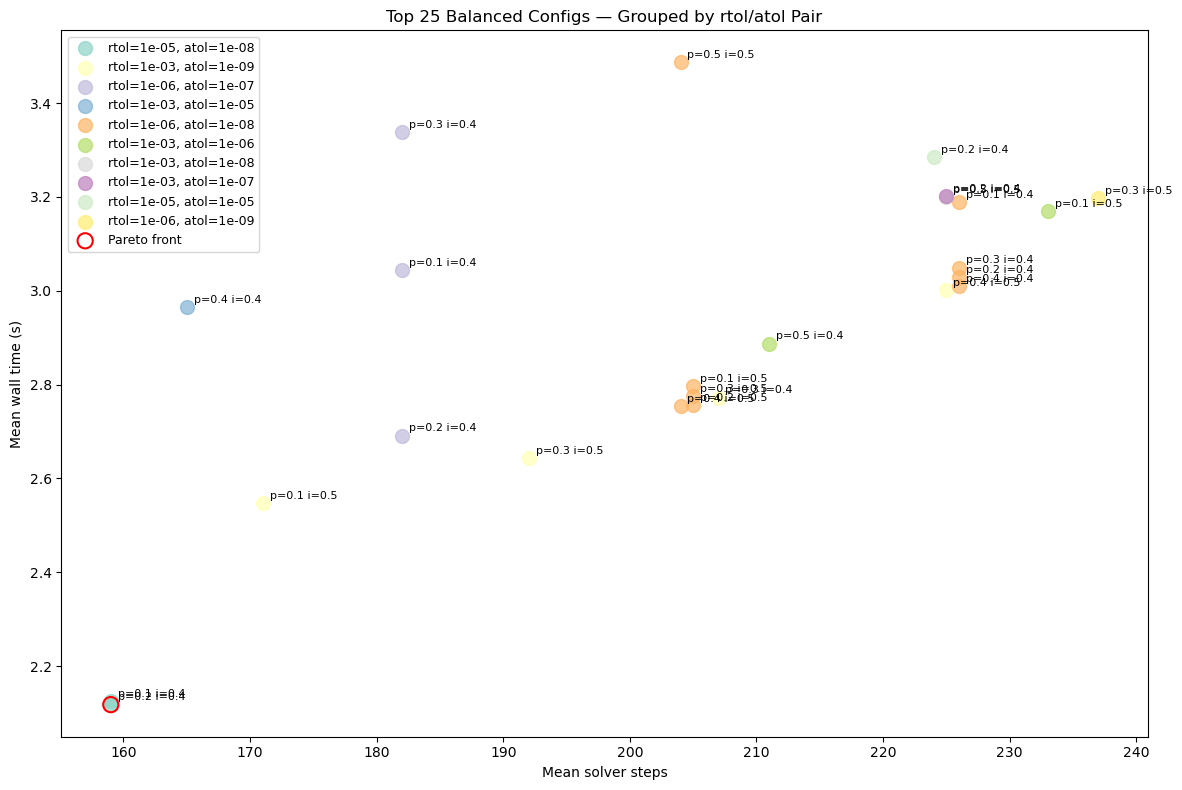

In [23]:
# Visual summary — top 10 balanced configurations, grouped by rtol/atol pair
num = 25
top = ok.sort_values('rank_sum').head(num).copy()

# Show which rtol/atol pairs and PIDs are in the top 10
print(f'Top {num} configs by balance:')
rtol_atol_pairs = top[['rtol', 'atol']].drop_duplicates()
print(f'rtol/atol pairs present:')
for _, pair in rtol_atol_pairs.iterrows():
    print(f'  rtol={pair["rtol"]:.0e}, atol={pair["atol"]:.0e}')
print(f'PID values present:', top[['pcoeff', 'icoeff', 'dcoeff']].drop_duplicates().values.tolist())

# Build PID-only label
def make_pid_label(row):
    return f"p={row['pcoeff']} i={row['icoeff']}"

top['label'] = top.apply(make_pid_label, axis=1)

fig, ax = plt.subplots(figsize=(12, 8))

# Color points by rtol/atol pair — plot each group separately for legend
colors = plt.cm.Set3(np.linspace(0, 1, len(rtol_atol_pairs)))
color_map = {tuple(row): colors[i] for i, row in enumerate(rtol_atol_pairs.values)}

for pair_idx, (_, pair_row) in enumerate(rtol_atol_pairs.iterrows()):
    rtol_val, atol_val = pair_row['rtol'], pair_row['atol']
    pair_data = top[(top['rtol'] == rtol_val) & (top['atol'] == atol_val)]
    color = color_map[(rtol_val, atol_val)]
    label = f"rtol={rtol_val:.0e}, atol={atol_val:.0e}"
    ax.scatter(
        pair_data['steps_mean'], pair_data['time_s_mean'],
        s=100, color=color, label=label, zorder=3, alpha=0.7
    )

# Annotate with PID only
for _, r in top.iterrows():
    ax.annotate(
        r['label'],
        xy=(r['steps_mean'], r['time_s_mean']),
        xytext=(5, 3),
        textcoords='offset points',
        fontsize=8,
    )

# Pareto front
pareto_idx = pareto_front_indices(top.reset_index(drop=True))
pareto_top = top.iloc[pareto_idx]
ax.scatter(
    pareto_top['steps_mean'], pareto_top['time_s_mean'],
    s=120, facecolors='none', edgecolors='red', linewidths=1.5,
    label='Pareto front', zorder=4,
)

ax.set_xlabel('Mean solver steps')
ax.set_ylabel('Mean wall time (s)')
ax.set_title(f'Top {num} Balanced Configs — Grouped by rtol/atol Pair')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Re-run the balanced winner once and return trajectories for downstream plotting
winner = best_balanced
solver_obj = getattr(dfrx, winner['solver'])()
adjoint_obj = getattr(dfrx, winner['adjoint'])()

sol = dfrx.diffeqsolve(
    dfrx.ODETerm(network),
    solver_obj,
    t0=time_range[0],
    t1=time_range[1],
    dt0=None if pd.isna(winner['dt0']) else float(winner['dt0']),
    y0=jnp.asarray(y0, dtype=jnp.float64),
    args=theta,
    saveat=dfrx.SaveAt(steps=True),
    stepsize_controller=dfrx.PIDController(
        rtol=float(winner['rtol']),
        atol=float(winner['atol']),
        pcoeff=float(winner['pcoeff']),
        icoeff=float(winner['icoeff']),
        dcoeff=float(winner['dcoeff']),
    ),
    adjoint=adjoint_obj,
    max_steps=int(winner['max_steps']),
)

num_accepted = int(np.asarray(sol.stats['num_accepted_steps']))
T = np.asarray(sol.ts[:num_accepted])
C = np.asarray(sol.ys[:num_accepted, :])

print(
    f"Winner: {winner['solver']} + {winner['adjoint']} | "
    f"rtol={winner['rtol']} atol={winner['atol']} dt0={winner['dt0']} "
    f"max_steps={int(winner['max_steps'])}"
)
print(f"Trajectory shape: T={T.shape}, C={C.shape}")

Winner: Kvaerno5 + RecursiveCheckpointAdjoint | rtol=1e-05 atol=1e-08 dt0=1e-06 max_steps=10000
Trajectory shape: T=(159,), C=(159, 320)


## Notes

- Results are machine- and load-dependent. Re-run the benchmark on the same hardware for fair comparisons.
- If this notebook will be used for gradient-based inference, validate adjoint stability separately; fastest forward solve is not always the most stable for reverse-mode gradients.
- Benchmark table is saved to `../Results/ODE Optimization/diffrax_solver_benchmark.csv`.

## Confirmation Benchmark

Tests the top solver configurations from the full-grid run across:
- different simulation time ranges
- different substrate/cofactor starting concentrations
- different enzyme starting concentrations

Each combination is timed and step-counted. Results are saved to
`../Results/ODE Optimization/diffrax_confirmation_benchmark.csv`.

After running, use the ranking cell below to confirm which config stays best
across regimes, and check whether any config becomes unreliable (fails or
produces inconsistent step counts) under particular conditions.

In [ ]:
# ── Confirmation benchmark ──────────────────────────────────────────────────
# Edit the four dictionaries below to set what gets tested.
# Solver/adjoint are held fixed at Kvaerno5 + RecursiveCheckpointAdjoint for
# all scenarios; only the numerical settings vary.

CONFIRM_SOLVER = 'Kvaerno5'
CONFIRM_ADJOINT = 'RecursiveCheckpointAdjoint'

CONFIRM_SOLVER_CONFIGS = {
    'winner':               dict(rtol=1e-5, atol=1e-8,  dt0=1e-6, max_steps=10000, pcoeff=0.2, icoeff=0.4, dcoeff=0.0),
    'runner_up':            dict(rtol=1e-5, atol=1e-8,  dt0=1e-6, max_steps=10000, pcoeff=0.1, icoeff=0.4, dcoeff=0.0),
    'loose_fast':           dict(rtol=1e-3, atol=1e-9,  dt0=1e-6, max_steps=10000, pcoeff=0.1, icoeff=0.5, dcoeff=0.0),
    'tighter':              dict(rtol=1e-6, atol=1e-7,  dt0=1e-6, max_steps=10000, pcoeff=0.2, icoeff=0.4, dcoeff=0.0),
    'loose_small_steps':    dict(rtol=1e-3, atol=1e-5,  dt0=1e-6, max_steps=10000, pcoeff=0.4, icoeff=0.4, dcoeff=0.0),
}

CONFIRM_TIME_RANGES = {
    'initial_rate':      (0.0, 150.0),
    'product_profile':   (0.0, 720.0),
}

# Substrate/cofactor scenarios — enzyme concentrations are set separately below
CONFIRM_SUBSTRATE_SCENARIOS = {
    'base': {
        sp.C2_AcCoA: 500.0, sp.C3_MalCoA: 500.0,
        sp.ACP: 10.0, sp.NADPH: 1000.0, sp.NADH: 1000.0,
    },
    'low_substrate': {
        sp.C2_AcCoA: 100.0, sp.C3_MalCoA: 100.0,
        sp.ACP: 10.0, sp.NADPH: 1000.0, sp.NADH: 1000.0,
    },
    'high_substrate': {
        sp.C2_AcCoA: 1000.0, sp.C3_MalCoA: 1000.0,
        sp.ACP: 20.0, sp.NADPH: 1000.0, sp.NADH: 1000.0,
    },
}

# Enzyme concentration scenarios (uM)
CONFIRM_ENZYME_SCENARIOS = {
    'base_enzymes': {
        sp.FabD: 1,  sp.FabH: 1,  sp.FabG: 1,  sp.FabZ: 1,
        sp.FabI: 1,  sp.TesA: 10, sp.FabF: 1,  sp.FabA: 1, sp.FabB: 1,
    },
    'low_enzymes': {
        sp.FabD: 0.1, sp.FabH: 0.1, sp.FabG: 0.1, sp.FabZ: 0.1,
        sp.FabI: 0.1, sp.TesA: 1.0, sp.FabF: 0.1, sp.FabA: 0.1, sp.FabB: 0.1,
    },
    'high_enzymes': {
        sp.FabD: 10,  sp.FabH: 10,  sp.FabG: 10,  sp.FabZ: 10,
        sp.FabI: 10,  sp.TesA: 100, sp.FabF: 10,  sp.FabA: 10, sp.FabB: 10,
    },
    'high_KS': {
        sp.FabD: 1,  sp.FabH: 10,   sp.FabG: 1,   sp.FabZ: 1,
        sp.FabI: 1,   sp.TesA: 10,  sp.FabF: 10,   sp.FabA: 1,  sp.FabB: 10,
    },
}

# ── Loop ────────────────────────────────────────────────────────────────────
solver_cls  = solver_factories[CONFIRM_SOLVER]
adjoint_cls = adjoint_factories[CONFIRM_ADJOINT]

confirm_rows = []
total = (
    len(CONFIRM_SOLVER_CONFIGS)
    * len(CONFIRM_TIME_RANGES)
    * len(CONFIRM_SUBSTRATE_SCENARIOS)
    * len(CONFIRM_ENZYME_SCENARIOS)
)
done = 0

for cfg_name, scfg in CONFIRM_SOLVER_CONFIGS.items():
    for tr_name, (t0, t1) in CONFIRM_TIME_RANGES.items():
        for sub_name, sub_concs in CONFIRM_SUBSTRATE_SCENARIOS.items():
            for enz_name, enz_concs in CONFIRM_ENZYME_SCENARIOS.items():

                # Build y0 for this scenario
                y0_run = np.zeros(len(species), dtype=np.float64)
                for idx, val in sub_concs.items():
                    y0_run[idx] = float(val)
                for idx, val in enz_concs.items():
                    y0_run[idx] = float(val)

                # Warm-up (first combination only per solver config)
                if done == 0 or (done % (len(CONFIRM_TIME_RANGES) * len(CONFIRM_SUBSTRATE_SCENARIOS) * len(CONFIRM_ENZYME_SCENARIOS)) == 0):
                    try:
                        _sol = dfrx.diffeqsolve(
                            dfrx.ODETerm(network), solver_cls(),
                            t0=t0, t1=t1, dt0=scfg['dt0'],
                            y0=jnp.asarray(y0_run, dtype=jnp.float64),
                            args=theta,
                            saveat=dfrx.SaveAt(steps=True),
                            stepsize_controller=dfrx.PIDController(
                                rtol=scfg['rtol'], atol=scfg['atol'],
                                pcoeff=scfg['pcoeff'], icoeff=scfg['icoeff'], dcoeff=scfg['dcoeff'],
                            ),
                            adjoint=adjoint_cls(),
                            max_steps=scfg['max_steps'],
                            throw=True,
                        )
                        jax.block_until_ready(_sol.ys)
                    except Exception:
                        pass

                # Timed trials
                trial_times, trial_steps, trial_accepted, trial_tfinal, errors = [], [], [], [], []
                for _rep in range(3):
                    try:
                        tic = time.perf_counter()
                        sol = dfrx.diffeqsolve(
                            dfrx.ODETerm(network), solver_cls(),
                            t0=t0, t1=t1, dt0=scfg['dt0'],
                            y0=jnp.asarray(y0_run, dtype=jnp.float64),
                            args=theta,
                            saveat=dfrx.SaveAt(steps=True),
                            stepsize_controller=dfrx.PIDController(
                                rtol=scfg['rtol'], atol=scfg['atol'],
                                pcoeff=scfg['pcoeff'], icoeff=scfg['icoeff'], dcoeff=scfg['dcoeff'],
                            ),
                            adjoint=adjoint_cls(),
                            max_steps=scfg['max_steps'],
                            throw=True,
                        )
                        jax.block_until_ready(sol.ys)
                        elapsed = time.perf_counter() - tic
                        stats = dict(sol.stats)
                        n_steps    = int(np.asarray(stats.get('num_steps', np.nan)))
                        n_accepted = int(np.asarray(stats.get('num_accepted_steps', np.nan)))
                        t_final    = float(np.asarray(sol.ts[n_accepted - 1])) if n_accepted > 0 else np.nan
                        trial_times.append(elapsed)
                        trial_steps.append(n_steps)
                        trial_accepted.append(n_accepted)
                        trial_tfinal.append(t_final)
                    except Exception as exc:
                        errors.append(str(exc))

                row = {
                    'solver_config':      cfg_name,
                    'time_range':         tr_name,
                    't0': t0, 't1': t1,
                    'substrate_scenario': sub_name,
                    'enzyme_scenario':    enz_name,
                    'solver':   CONFIRM_SOLVER,
                    'adjoint':  CONFIRM_ADJOINT,
                    **{k: scfg[k] for k in ('rtol','atol','dt0','max_steps','pcoeff','icoeff','dcoeff')},
                    'n_trials':  len(trial_times),
                    'n_errors':  len(errors),
                    'error_example': errors[0] if errors else None,
                    'success_all': len(trial_times) > 0 and len(errors) == 0,
                    'time_s_mean':          float(np.mean(trial_times))    if trial_times else np.nan,
                    'time_s_std':           float(np.std(trial_times))     if trial_times else np.nan,
                    'steps_mean':           float(np.mean(trial_steps))    if trial_steps else np.nan,
                    'accepted_steps_mean':  float(np.mean(trial_accepted)) if trial_accepted else np.nan,
                    't_final_mean':         float(np.mean(trial_tfinal))   if trial_tfinal else np.nan,
                }
                confirm_rows.append(row)
                done += 1
                if done % 10 == 0 or done == total:
                    print(f'Completed {done}/{total}  ({cfg_name} | {tr_name} | {sub_name} | {enz_name})')

confirm_results = pd.DataFrame(confirm_rows)
confirm_path = '../Results/ODE Optimization/diffrax_confirmation_benchmark.csv'
confirm_results.to_csv(confirm_path, index=False)
print(f'\nSaved {len(confirm_results)} rows to {confirm_path}')
confirm_results.head()

Completed 10/120  (winner | initial_rate | high_substrate | low_enzymes)
Completed 20/120  (winner | product_profile | low_substrate | high_KS)
Completed 30/120  (runner_up | initial_rate | low_substrate | low_enzymes)
Completed 40/120  (runner_up | product_profile | base | high_KS)
Completed 50/120  (loose_fast | initial_rate | base | low_enzymes)
Completed 60/120  (loose_fast | initial_rate | high_substrate | high_KS)
Completed 70/120  (loose_fast | product_profile | high_substrate | low_enzymes)
Completed 80/120  (tighter | initial_rate | low_substrate | high_KS)
Completed 90/120  (tighter | product_profile | low_substrate | low_enzymes)
Completed 100/120  (loose_small_steps | initial_rate | base | high_KS)
Completed 110/120  (loose_small_steps | product_profile | base | low_enzymes)
Completed 120/120  (loose_small_steps | product_profile | high_substrate | high_KS)

Saved 120 rows to ../Results/diffrax_confirmation_benchmark.csv


,solver_config,time_range,t0,t1,substrate_scenario,enzyme_scenario,solver,adjoint,rtol,atol,...,dcoeff,n_trials,n_errors,error_example,success_all,time_s_mean,time_s_std,steps_mean,accepted_steps_mean,t_final_mean
0,winner,initial_rate,0.0,150.0,base,base_enzymes,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,1.000000e-08,...,0.0,3,0,None,True,1.922038,0.060151,141.0,141.0,150.0
1,winner,initial_rate,0.0,150.0,base,low_enzymes,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,1.000000e-08,...,0.0,3,0,None,True,2.575709,0.096872,182.0,157.0,150.0
2,winner,initial_rate,0.0,150.0,base,high_enzymes,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,1.000000e-08,...,0.0,3,0,None,True,2.302825,0.161260,155.0,155.0,150.0
3,winner,initial_rate,0.0,150.0,base,high_KS,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,1.000000e-08,...,0.0,3,0,None,True,6.882336,0.570463,432.0,342.0,150.0
4,winner,initial_rate,0.0,150.0,low_substrate,base_enzymes,Kvaerno5,RecursiveCheckpointAdjoint,0.00001,1.000000e-08,...,0.0,3,0,None,True,5.381758,0.360209,374.0,296.0,150.0


In [ ]:
# ── Confirmation ranking ────────────────────────────────────────────────────
ck = confirm_results[confirm_results['success_all']].copy()
ck = ck[np.isfinite(ck['time_s_mean']) & np.isfinite(ck['steps_mean'])]

if ck.empty:
    print('No successful confirmation runs.')
else:
    # Consistency: count successes per solver config across all scenarios
    success_counts = (
        confirm_results.groupby('solver_config')['success_all']
        .agg(['sum', 'count'])
        .rename(columns={'sum': 'n_success', 'count': 'n_total'})
    )
    success_counts['success_rate'] = success_counts['n_success'] / success_counts['n_total']
    print('Success rate by solver config:')
    display(success_counts)

    # Mean time and steps per solver config, averaged over all scenarios
    agg = (
        ck.groupby('solver_config')[['time_s_mean', 'steps_mean', 'accepted_steps_mean']]
        .mean()
        .sort_values('time_s_mean')
    )
    print('\nMean time/steps across all scenarios per solver config:')
    display(agg)

    # Best config per time-range × substrate × enzyme scenario
    idx_best = ck.groupby(['time_range', 'substrate_scenario', 'enzyme_scenario'])['time_s_mean'].idxmin()
    best_per_scenario = ck.loc[idx_best][
        ['time_range', 'substrate_scenario', 'enzyme_scenario', 'solver_config',
         'rtol', 'atol', 'pcoeff', 'icoeff', 'time_s_mean', 'steps_mean']
    ].reset_index(drop=True)
    print('\nFastest solver config per scenario:')
    display(best_per_scenario)

    # Pivot: time_s_mean by solver_config × scenario label
    ck['scenario'] = ck['time_range'] + ' | ' + ck['substrate_scenario'] + ' | ' + ck['enzyme_scenario']
    pivot = ck.pivot_table(index='scenario', columns='solver_config', values='time_s_mean')
    print('\nWall time (s) per scenario × solver config:')
    display(pivot.round(3))

    confirm_results.to_csv('../Results/ODE Optimization/diffrax_confirmation_benchmark.csv', index=False)

Success rate by solver config:


,n_success,n_total,success_rate
solver_config,,,
loose_fast,24,24,1.0
loose_small_steps,24,24,1.0
runner_up,24,24,1.0
tighter,24,24,1.0
winner,24,24,1.0



Mean time/steps across all scenarios per solver config:


,time_s_mean,steps_mean,accepted_steps_mean
solver_config,,,
winner,5.591570,355.250000,280.250000
runner_up,6.795175,385.708333,295.041667
loose_small_steps,7.076895,387.208333,245.500000
tighter,7.667740,395.708333,307.166667
loose_fast,8.128159,354.000000,227.625000



Fastest solver config per scenario:


,time_range,substrate_scenario,enzyme_scenario,solver_config,rtol,atol,pcoeff,icoeff,time_s_mean,steps_mean
0,initial_rate,base,base_enzymes,winner,0.000010,1.000000e-08,0.2,0.4,1.922038,141.0
1,initial_rate,base,high_KS,loose_small_steps,0.001000,1.000000e-05,0.4,0.4,4.628761,278.0
2,initial_rate,base,high_enzymes,loose_fast,0.001000,1.000000e-09,0.1,0.5,1.440979,79.0
3,initial_rate,base,low_enzymes,winner,0.000010,1.000000e-08,0.2,0.4,2.575709,182.0
4,initial_rate,high_substrate,base_enzymes,runner_up,0.000010,1.000000e-08,0.1,0.4,1.887608,140.0
5,initial_rate,high_substrate,high_KS,runner_up,0.000010,1.000000e-08,0.1,0.4,3.264546,203.0
6,initial_rate,high_substrate,high_enzymes,loose_small_steps,0.001000,1.000000e-05,0.4,0.4,1.733896,93.0
7,initial_rate,high_substrate,low_enzymes,runner_up,0.000010,1.000000e-08,0.1,0.4,8.401809,636.0
8,initial_rate,low_substrate,base_enzymes,loose_fast,0.001000,1.000000e-09,0.1,0.5,3.568840,140.0
9,initial_rate,low_substrate,high_KS,runner_up,0.000010,1.000000e-08,0.1,0.4,2.316294,144.0



Wall time (s) per scenario × solver config:


solver_config,loose_fast,loose_small_steps,runner_up,tighter,winner
scenario,,,,,
initial_rate | base | base_enzymes,2.535,2.352,2.142,3.984,1.922
initial_rate | base | high_KS,4.860,4.629,5.434,8.501,6.882
initial_rate | base | high_enzymes,1.441,2.084,2.596,3.548,2.303
initial_rate | base | low_enzymes,17.741,9.751,8.177,12.076,2.576
initial_rate | high_substrate | base_enzymes,5.853,7.659,1.888,2.572,3.689
initial_rate | high_substrate | high_KS,3.345,3.494,3.265,4.831,5.845
initial_rate | high_substrate | high_enzymes,1.859,1.734,2.614,3.272,3.027
initial_rate | high_substrate | low_enzymes,21.427,9.957,8.402,15.680,16.373
initial_rate | low_substrate | base_enzymes,3.569,5.552,8.260,4.933,5.382


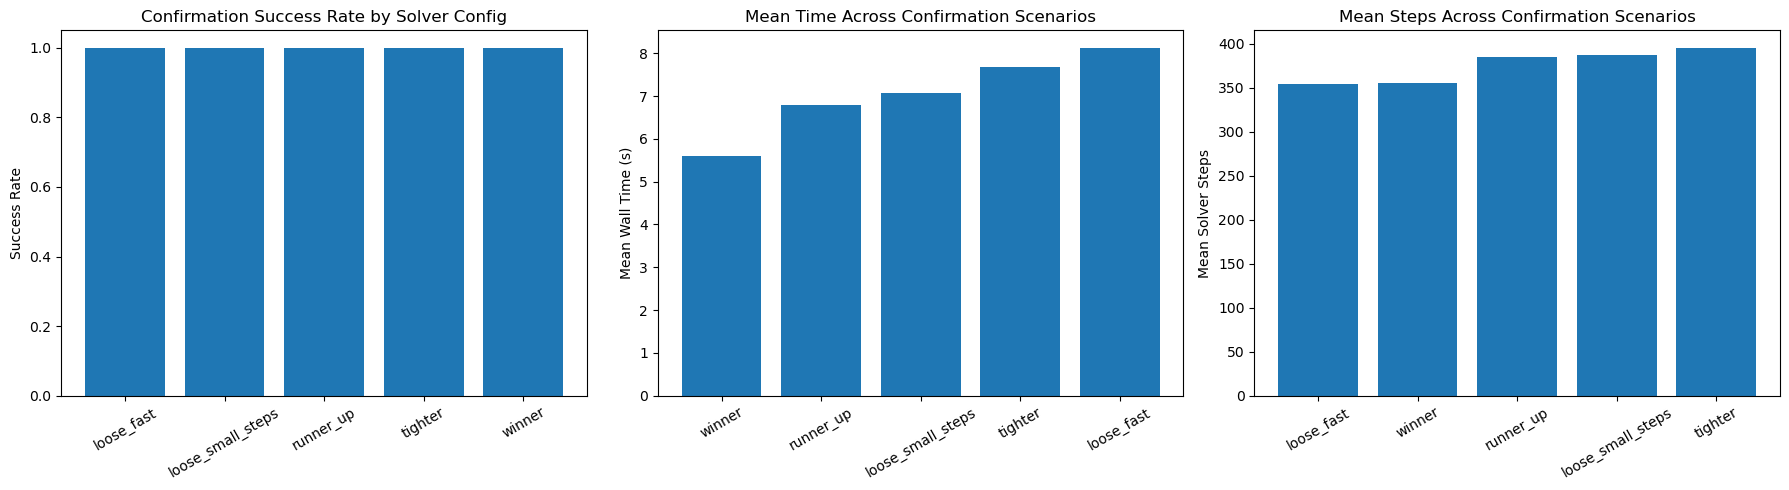

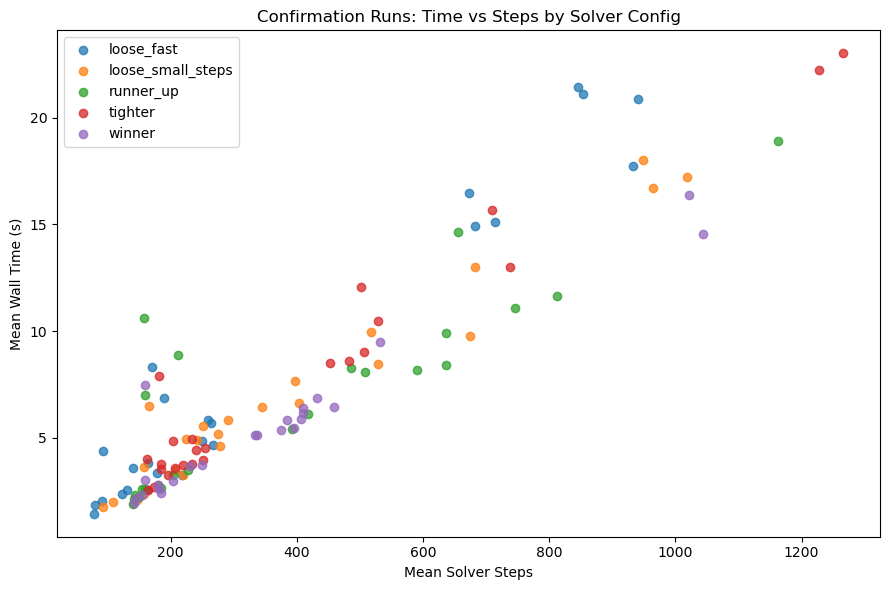

In [25]:
# ── Confirmation plots ──────────────────────────────────────────────────────
if 'confirm_results' not in globals():
    raise RuntimeError('Run the confirmation benchmark cell first.')

cr = confirm_results.copy()

# 1) Success rate by solver configuration
success = (
    cr.groupby('solver_config')['success_all']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'n_success', 'count': 'n_total'})
)
success['success_rate'] = success['n_success'] / success['n_total']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax0, ax1, ax2 = axes

ax0.bar(success.index, success['success_rate'])
ax0.set_ylim(0, 1.05)
ax0.set_ylabel('Success Rate')
ax0.set_title('Confirmation Success Rate by Solver Config')
ax0.tick_params(axis='x', rotation=30)

# 2) Mean wall time by solver configuration (all successful scenarios)
okc = cr[(cr['success_all']) & np.isfinite(cr['time_s_mean']) & np.isfinite(cr['steps_mean'])].copy()
if okc.empty:
    raise RuntimeError('No successful confirmation runs to plot.')

mean_time = okc.groupby('solver_config')['time_s_mean'].mean().sort_values()
ax1.bar(mean_time.index, mean_time.values)
ax1.set_ylabel('Mean Wall Time (s)')
ax1.set_title('Mean Time Across Confirmation Scenarios')
ax1.tick_params(axis='x', rotation=30)

# 3) Mean steps by solver configuration
mean_steps = okc.groupby('solver_config')['steps_mean'].mean().sort_values()
ax2.bar(mean_steps.index, mean_steps.values)
ax2.set_ylabel('Mean Solver Steps')
ax2.set_title('Mean Steps Across Confirmation Scenarios')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Scenario-level scatter (time vs steps), colored by solver config
fig, ax = plt.subplots(figsize=(9, 6))
for cfg_name, df_cfg in okc.groupby('solver_config'):
    ax.scatter(df_cfg['steps_mean'], df_cfg['time_s_mean'], label=cfg_name, alpha=0.75)

ax.set_xlabel('Mean Solver Steps')
ax.set_ylabel('Mean Wall Time (s)')
ax.set_title('Confirmation Runs: Time vs Steps by Solver Config')
ax.legend()
plt.tight_layout()
plt.show()